In [ ]:
#Import the necessary libraries and files 
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.utils import shuffle

In [8]:
project_path = Path("/content/drive/MyDrive/ISL_GAN_FewShot_Project")
landmark_dir = project_path / "data" / "landmarks"
augmented_dir = project_path / "data" / "augmented"
augmented_dir.mkdir(parents=True, exist_ok=True)

print("Landmark dir:", landmark_dir)
print("Augmented dir:", augmented_dir)

Landmark dir: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks
Augmented dir: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/augmented


In [ ]:
# --- Data Loading Section ---
# Load the primary training dataset and its corresponding labels
X_train = np.load(landmark_dir / "X_train.npy")
y_train = np.load(landmark_dir / "y_train.npy")

# Load the validation set used for hyperparameter tuning and monitoring overfit
X_val = np.load(landmark_dir / "X_val.npy")
y_val = np.load(landmark_dir / "y_val.npy")

# Load the final test set for unbiased evaluation of the model
X_test = np.load(landmark_dir / "X_test.npy")
y_test = np.load(landmark_dir / "y_test.npy")

# Load augmented or synthetically generated data to bolster the training process
X_synthetic = np.load(landmark_dir / "X_synthetic.npy")
y_synthetic = np.load(landmark_dir / "y_synthetic.npy")

# --- Mapping & Metadata Section ---
# Open the JSON file containing the relationship between class names and numeric indices
with open(landmark_dir / "class_mapping.json", "r") as f:
    mapping = json.load(f)

# Extract the forward mapping (ClassName -> Integer)
class_to_idx = mapping["class_to_idx"]

# Reconstruct the reverse mapping (Integer -> ClassName)
# Note: JSON keys are strings, so we convert them to integers for array indexing
idx_to_class = {int(k): v for k, v in mapping["idx_to_class"].items()}

# --- Verification Section ---
# Display shapes to ensure data integrity and check the balance of synthetic vs. real data
print("Real train:", X_train.shape, y_train.shape)
print("Synthetic:", X_synthetic.shape, y_synthetic.shape)

Real train: (170, 63) (170,)
Synthetic: (1750, 63) (1750,)


In [10]:
X_augmented = np.concatenate([X_train, X_synthetic], axis=0)
y_augmented = np.concatenate([y_train, y_synthetic], axis=0)

X_augmented, y_augmented = shuffle(X_augmented, y_augmented, random_state=42)

print("Augmented X shape:", X_augmented.shape)
print("Augmented y shape:", y_augmented.shape)

Augmented X shape: (1920, 63)
Augmented y shape: (1920,)


In [11]:
np.save(augmented_dir / "X_augmented.npy", X_augmented)
np.save(augmented_dir / "y_augmented.npy", y_augmented)

print("Augmented dataset saved successfully.")

Augmented dataset saved successfully.


In [12]:
feature_cols = [f"f{i}" for i in range(X_augmented.shape[1])]

aug_df = pd.DataFrame(X_augmented, columns=feature_cols)
aug_df["class_name"] = [idx_to_class[i] for i in y_augmented]

aug_csv = augmented_dir / "augmented_landmarks.csv"
aug_df.to_csv(aug_csv, index=False)

print("Augmented CSV saved to:", aug_csv)
aug_df.head()

Augmented CSV saved to: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/augmented/augmented_landmarks.csv


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f54,f55,f56,f57,f58,f59,f60,f61,f62,class_name
0,0.000003,0.000010,0.000006,-0.014507,-0.051664,0.030179,0.109253,0.191793,0.051574,-0.174057,...,0.258049,0.358514,-0.191760,0.207024,0.360563,-0.187409,0.015822,0.303784,-0.146365,H
1,0.000002,0.000011,0.000006,-0.022873,-0.054840,0.032680,0.106452,0.195757,0.044846,-0.201349,...,0.234279,0.348420,-0.198072,0.192142,0.361252,-0.174600,-0.016222,0.310794,-0.148805,U
2,0.000561,0.001389,0.001090,-0.027280,-0.041126,0.008140,0.072247,0.112316,0.008225,-0.095027,...,0.152641,0.228153,-0.152339,0.124240,0.292074,-0.149601,-0.014148,0.221078,-0.128043,9
3,0.000175,0.000525,0.000414,-0.025070,-0.049571,0.019229,0.081145,0.147949,0.022284,-0.137216,...,0.147322,0.249336,-0.156211,0.153823,0.310774,-0.154654,-0.044518,0.255783,-0.129391,7
4,0.001744,0.003699,0.003501,-0.017234,-0.043649,0.001447,0.082661,0.088986,-0.001199,-0.083160,...,0.112829,0.188872,-0.142963,0.082179,0.255202,-0.142053,-0.010171,0.173741,-0.120809,5


In [14]:
import matplotlib.pyplot as plt

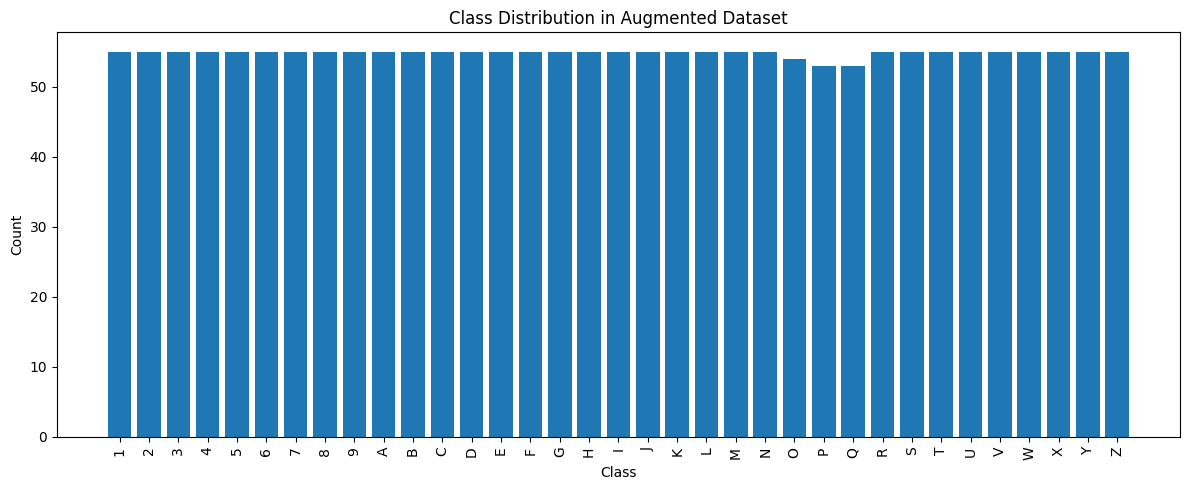

In [15]:
class_counts = pd.Series(y_augmented).value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar([idx_to_class[i] for i in class_counts.index], class_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in Augmented Dataset")
plt.tight_layout()
plt.show()